# Plot the rupture profile on the slip velocity

2024.6.19 Kurama Okubo

Plot the rupture profile on the slip velocity.

2025.11.29 Update for the reply to the comment of the first revision.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib.colors as colors

%matplotlib inline
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings
import time

from importParaviewColormap import importParaviewColormap

%load_ext autoreload
%autoreload 2

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True

plt.rcParams['axes.linewidth'] = 0.75

In [2]:
figdir = "../figure/"
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [3]:
E = 96e9
nu = 0.246 # metagabbro
mu = E/(2*(1+nu))

a_patch = 4.0e-3
a_nuc = 2.5e-3 # nucleation radius 

nb_x_elements = 1024 #128 #1024
nb_z_elements = 1024 #128 #1024


Ifmasteroutput=True # add file key to the master output
if Ifmasteroutput:
    filekey = "_master"
else:
    filekey = ""

In [4]:
# case study parameter casename
a_patch = 4.0e-3
a_nuc = 2.5e-3
a_margin = 4.08e-3

rupturetype = "pulse"
pdcscaling = 0.60 #0.65
bgbeta= 0.35 #0.4

sig_n = 6e6

IfBinaryOutput = True

casestr = f"a={a_patch*1e3:.2f}_ruptype={rupturetype}_pdcscaling={pdcscaling:.3f}_sn={sig_n/1e6:.1f}MPa_hatfr=0.3_bgbeta={bgbeta:.2f}"

finame=f"../../SmoothSelfHeal/preprocess_modelsetup/data/gouge_dynamicrupture_modelparam_{casestr}{filekey}.csv"

# Read model parameters
df_modelparam = pd.read_csv(finame, index_col=0)

datadir_root = "/Volumes/Okuboetal2025_masterHDD/RuptureSimulation/main_casestudy/build_hpcv64_mastercase_v4/simulations_main_casestudy_hpc_master"

casestr

'a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35'

In [5]:
df_modelparam.head()

,M0_mean,Tw_mean,Mw_mean,hat_sn_patch,hat_sn_background,delsig_withmargin_try,slip_try,initialstress_fraction,delsigma_factor,fp_patch,...,GIIC_patch,GIIC_background,Sratio_nuc,Sratio_patch,Ainit_nuc,Ainit_patch,Anuc_nuc,Anuc_patch,rnuc_nuc,rnuc_patch
gougeevent_id,,,,,,,,,,,,,,,,,,,,,
4,0.594031,0.000003,-6.220794,6000000.0,2000000.0,3826544.690,2.948600e-07,0.925,0.6,0.738005,...,0.063683,0.0,0,0.144648,3.82,3.827647,0.000002,0.000002,0.783375,0.784159
9,0.047135,0.000002,-6.954435,6000000.0,2000000.0,303630.180,2.339667e-08,0.925,0.6,0.357149,...,0.001817,0.0,0,0.882198,3.82,5.050491,0.000005,0.000007,1.312687,1.509373
18,0.757592,0.000003,-6.150376,6000000.0,2000000.0,4880150.680,3.760471e-07,0.925,0.6,0.851908,...,0.092850,0.0,0,0.130924,3.82,3.825779,0.000002,0.000002,0.719379,0.719923
19,0.056071,0.000002,-6.904172,6000000.0,2000000.0,361193.127,2.783226e-08,0.925,0.6,0.363372,...,0.002236,0.0,0,0.754525,3.82,4.613050,0.000005,0.000007,1.313740,1.443683
20,0.867075,0.000003,-6.111295,6000000.0,2000000.0,5585402.460,4.303913e-07,0.925,0.6,0.928152,...,0.114592,0.0,0,0.124631,3.82,3.825032,0.000001,0.000001,0.685382,0.685833


In [6]:
# Select gouge event id to plot the snapshots
expr_id = 87
gougeevent_id = 72

In [7]:
df_modelparam_selected = df_modelparam[df_modelparam.index == gougeevent_id]
simulation_name = f"fb03-{expr_id:03d}__{df_modelparam_selected.index[0]:04d}_{casestr}_{df_modelparam_selected.delsigma_factor.values[0]:.4f}"
print(f"Process {gougeevent_id}: {simulation_name}")


Process 72: fb03-087__0072_a=4.00_ruptype=pulse_pdcscaling=0.600_sn=6.0MPa_hatfr=0.3_bgbeta=0.35_0.4300


In [8]:
figdir_profile_master = f"{figdir}/{simulation_name}"
if not os.path.exists(figdir_profile_master):
    os.makedirs(figdir_profile_master)

## Set the model parameters

In [9]:
df_time = pd.read_csv(os.path.join(datadir_root,simulation_name+".time"), header=None, sep=' ', index_col=0)
df_coord = pd.read_csv(os.path.join(datadir_root,simulation_name+".coords"), header=None, sep=' ', index_col=None)
NT=len(df_time)


In [10]:
R_nuc = df_modelparam_selected.rnuc_patch.values[0]*1e-3 
Lc = 2*R_nuc # [m] we define the Lc as the diameter of the nucleation circle

In [11]:
# location of the center of nucleation zone
nuc_x = -(a_patch - a_nuc)
nuc_z = 0

xcoord = df_coord.loc[:,0].values
zcoord = df_coord.loc[:,2].values

x_length = xcoord.max()
z_length = zcoord.max()

# ref also: https://stackoverflow.com/a/35176314

X = xcoord.reshape(nb_x_elements,nb_z_elements).T - x_length/2
Z = zcoord.reshape(nb_x_elements,nb_z_elements).T - z_length/2

dz = (zcoord[1] - zcoord[0])
print(f"Grid size: {dz*1e3}[mm]") 

Grid size: 0.0390625[mm]


## Read data

In [12]:
read_comp = 0 #0: Mode II direction, 1: normal (Mode I), 2:Mode III direction 

# read velocity
read_parameter = f"top_velo_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_vel = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_vel = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")
    
# read displacement
read_parameter = f"top_disp_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_disp = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_disp = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")

# read cohesion (shear traction)
read_parameter = f"cohesion_{read_comp}" # select the parameter to read
if IfBinaryOutput:
    D = np.fromfile(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), dtype="float32")
    df_data_coh = pd.DataFrame(data=D.reshape((NT, -1)))
else:
    df_data_coh = pd.read_csv(os.path.join(datadir_root,simulation_name+f"-DataFiles/{read_parameter}.out"), header=None, sep=' ', engine="c")


# check if the grid size is consistent to the data shape
assert len(df_data_vel.columns) == len(xcoord)
assert len(df_data_disp.columns) == len(xcoord)
assert len(df_data_coh.columns) == len(xcoord)


# Compute the rupture profile
Process flow:

1. extract the data along x axis
2. plot x-t axis

In [13]:
center_z = zcoord[np.where(zcoord-z_length/2>0)[0][0]]
center_x_index = df_coord[df_coord[2] == center_z].index

In [14]:
df_data_vel_x = df_data_vel.loc[:, center_x_index]
df_data_disp_x = df_data_disp.loc[:, center_x_index]
df_data_coh_x = df_data_coh.loc[:, center_x_index]

In [15]:
xcoord_vec = np.unique(xcoord)
xq, tq = np.meshgrid(xcoord_vec-x_length/2, df_time)

In [16]:
tq.shape

(614, 1024)

In [17]:
2*df_data_vel.max().max(), 2*df_data_vel.min().min(), 2*df_data_disp.max().max()*1e6, df_data_coh.max().max()/1e6

(1.082680106163025, -0.0030902246944606304, 0.3241305250867299, 4.461122)

In [18]:
cmap_vel = importParaviewColormap("pararainbow_uni_w"+".json", False)


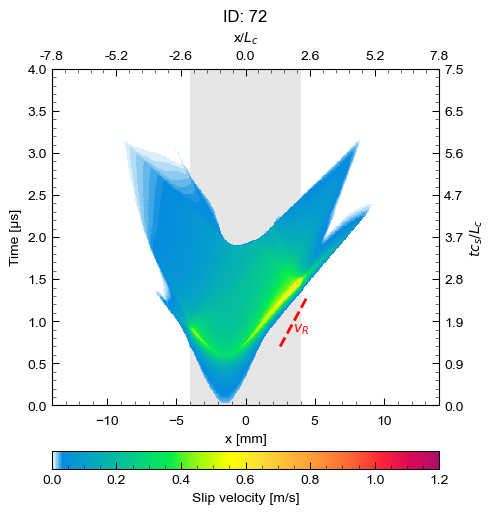

In [19]:
cs = 3600

vmax_vel = 1.2
vmin_vel = 0.0 #-0.5

xlimit = [-6, 6]
ylimit = [0, 4]

value_factor_double = 2.0 # double the value for slip and slip velocity

patch_highlight = True

fig, [ax, cax] = plt.subplots(2, 1, figsize=(5, 5.2), gridspec_kw={'height_ratios': [0.95, 0.05]})
fig.subplots_adjust(hspace=0.26)

# contourf was tricky to define the color range
# levels = 100
# levels = np.linspace(vmin_vel, vmax_vel, 101)
# h1 = ax.contourf(xq*1e3, tq*1e6, value_factor_double*df_data_vel_x, levels, norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel), cmap='turbo') # multiply 2 for slip velocity
# for c in h1.collections:
    # c.set_rasterized(True)

# Plot patch width
# ax.plot([a_patch*1e3, a_patch*1e3], [0, 8], "--", c="gray", lw=1)
# ax.plot([-a_patch*1e3, -a_patch*1e3], [0, 8], "--", c="gray", lw=1)
# ax.axvspan(-a_patch*1e3,  a_patch*1e3, alpha=0.5, color='red')

# Set small values to highlight patch area
# Note: In this plot, we ignored the negative slip velocity although almost no negative slip exists.
data_vel_x_filled = np.zeros(df_data_vel_x.shape)
vel_eps = 0.002
for i, data in df_data_vel_x.iterrows():
    # set small velocity in the patch
    if patch_highlight:
        data.values[(2*data.values < vel_eps)] = vel_eps
        data.values[(np.abs(xq[0]) < a_patch) & (2*data.values < 10*vel_eps)] = -100
        
    data_vel_x_filled[i, :] = data.values

cmap_vel.set_under([0.9, 0.9, 0.9])

h1 = ax.pcolormesh(xq*1e3, tq*1e6, value_factor_double*data_vel_x_filled, #value_factor_double*df_data_vel_x,
                   norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel),
                   cmap=cmap_vel, rasterized=True) # multiply 2 for slip velocity

# plot contour line
# contour_levels=[0.01]
# h2 = ax.contour(xq*1e3, tq*1e6, value_factor_double*df_data_vel_x, levels=contour_levels,
#                colors="k", linewidths=1.25) # multiply 2 for slip velocity

def fmt(x):
    return f"{x:.2g}" # mm/s"

# ref: https://stackoverflow.com/a/13015194
# manual_locations = [(2, 0.6), (2, 1), (-2, 0.5), (1.7, 1.2)]
# ax.clabel(h2, h2.levels, inline=False, fmt=fmt, fontsize=12, manual=manual_locations)

# adjust the location of annotation
if gougeevent_id==91:
    annot_loc = [(2.35, 0.55), (0.85, 1.0), (0.3, 2.025), (0.18, 2.525)]
elif gougeevent_id==30:
    annot_loc = [(2.35, 0.55), (1.5, 1.45), (0.5, 2.275), (0.18, 2.725)]
else:
    annot_loc = [(2.425, 0.55), (1.2, 0.95), (0.3, 1.775), (0.18, 2.25)]


# for i, lev in enumerate(contour_levels):
#     ax.text(annot_loc[i][0], annot_loc[i][1], fmt(lev), color="k")

# ax.text(2.375, 0.35, "[mm/s]")
ax.set_title(f"ID: {gougeevent_id}")
ax.set_xlim([-14, 14])
ax.set_ylim(ylimit)
ax.set_xlabel("x [mm]")
ax.set_ylabel("Time [μs]")

# plot reference of rupture speed
vscale_len = 2;
v_dt = 1; #[us]
v_x0= 2.5; #[mm]
v_t0= 0.7; #[us]

dx_cs = (cs*1e-3)*v_dt; # compute with [mm/us]
dx_cr = 0.92*(cs*1e-3)*v_dt;

# th_vp = np.arctan2(dx_vp, v_dt);
th_vs = np.arctan2(v_dt, dx_cs);
th_vr = np.arctan2(v_dt, dx_cr);

# plot([v_t0, v_t0+vscale_len/tan(th_vp)], [v_x0, v_x0-vscale_len], "k-")
# ax.plot([v_x0, v_x0+vscale_len], [v_t0, v_t0+vscale_len*np.tan(th_vs)], "k-")
ax.plot([v_x0, v_x0+vscale_len], [v_t0, v_t0+vscale_len*np.tan(th_vr)], "--", c="r", lw=2)

# text(6, 0.92, "c_p", "FontSize",17);
# ax.text(6.7, 0.92, "c_s");
ax.text(4.0, 0.88, "$v_R$", ha="center", c="r");

# plot nucleation zone
refy = 0.1
# ax.annotate('', xy=((nuc_x - R_nuc)*1e3, refy), xytext=((nuc_x + R_nuc)*1e3, refy),
            # arrowprops=dict(arrowstyle='-'), annotation_clip=True)
annotstr = r" 2$R_c$"
# ax.text(nuc_x*1e3, 0.13, annotstr, ha="center", va='bottom')
# # axs[1].plot([refstarttime, refendtime], [-0.3, -0.3], clip_on=False,)

# plot twin axes for the non dimensional values

ax.tick_params(axis='x', which='major', pad=7)

# nondimensional space
def x2nondim(x, Lc):
    return x/Lc

ax2 = ax.twiny()
ax2.set_xlim(xlimit) # synchronize with the first axis
ax2_xticks = ax.get_xticks()
ax2.set_xticks(ax2_xticks, labels=[f"{x:.1f}" for x in x2nondim(ax2_xticks*1e-3, Lc)])
ax2.tick_params(axis='x', pad=5)

xlabelstr2 = r"x/$L_c$"
ax2.set_xlabel(xlabelstr2, labelpad=6)

# nondimensional time
def t2nondim(t, cs, Lc):
    return t*cs/Lc
    
ax3 = ax.twinx()
ax3.set_ylim(ylimit) # synchronize with the first axis
ax3_yticks = ax.get_yticks()
ax3.set_yticks(ax3_yticks, labels=[f"{x:.1f}" for x in t2nondim(ax3_yticks*1e-6, cs, Lc)])


ylabelstr3 = r"$tc_s/L_c$"
ax3.set_ylabel(ylabelstr3)

cb_vel = fig.colorbar(h1, cax=cax, orientation="horizontal", shrink=1.0, norm=colors.Normalize(vmin=vmin_vel, vmax=vmax_vel) )#ticks=cticks)
cb_vel.set_label("Slip velocity [m/s]")


plt.savefig(figdir_profile_master + "/master_ruptureprofile_{}_comp{}.png".format(simulation_name, read_comp), dpi=300, bbox_inches="tight")
plt.savefig(figdir_profile_master + "/master_ruptureprofile_{}_comp{}.pdf".format(simulation_name, read_comp), bbox_inches="tight")
plt.savefig(figdir_profile_master + "/master_ruptureprofile_{}_comp{}.eps".format(simulation_name, read_comp), bbox_inches="tight")


In [20]:
x = df_data_vel_x.values[np.abs(xq) <= a_patch]